In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import openai
import json
import os
from dotenv import load_dotenv
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("All imports successful!")

/home/aniketnerali16/fraud_detection/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


In [7]:
X_train = pd.read_csv('/home/aniketnerali16/fraud_detection/data/X_train.csv')
X_test  = pd.read_csv('/home/aniketnerali16/fraud_detection/data/X_test.csv')
y_train = pd.read_csv('/home/aniketnerali16/fraud_detection/data/y_train.csv').iloc[:, 0].reset_index(drop=True)
y_test  = pd.read_csv('/home/aniketnerali16/fraud_detection/data/y_test.csv').iloc[:, 0].reset_index(drop=True)


X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

# Verify shapes
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Unique labels: {y_test.unique()}")


X_train: (472432, 233)
X_test:  (118108, 233)
y_train: (472432,)
y_test:  (118108,)
Unique labels: [0 1]


In [8]:
fraud_count = y_train.sum()
legit_count = len(y_train) - fraud_count
scale       = legit_count / fraud_count

print("Retraining XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"y_prob shape: {y_prob.shape}")
print(f"y_test shape: {y_test.shape}")

auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.3f}")
print("Model ready!")


Retraining XGBoost...
y_prob shape: (118108,)
y_test shape: (118108,)
AUC: 0.931
Model ready!


In [9]:
print("Computing SHAP values — this takes 3-5 minutes...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete!")

Computing SHAP values — this takes 3-5 minutes...
SHAP values shape: (118108, 233)
SHAP computation complete!


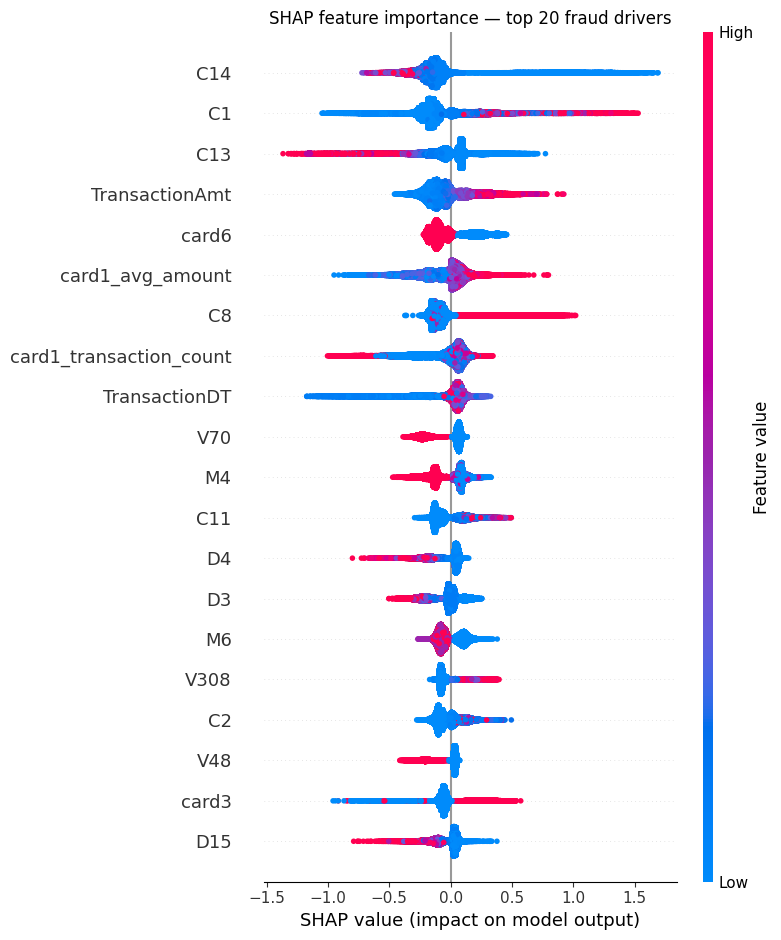

SHAP summary plot saved!


In [10]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    max_display=20,
    show=False
)
plt.title('SHAP feature importance — top 20 fraud drivers')
plt.tight_layout()
plt.savefig('/home/aniketnerali16/fraud_detection/models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

In [11]:
results_df = X_test.copy()
results_df['fraud_probability'] = y_prob
results_df['predicted_fraud']  = y_pred
results_df['actual_fraud'] = y_test.values

#Focus on high confidence fraud predictions
high_risk = results_df[
    (results_df['predicted_fraud'] == 1) &
    (results_df['fraud_probability'] > 0.7)
].copy()

print(f"High risk transactions flagged: {len(high_risk):,}")
print(f"Actual fraud in this group:     {high_risk['actual_fraud'].sum():,}")
print(f"Precision at 0.7 threshold:     {high_risk['actual_fraud'].mean()*100:.1f}%")


display(high_risk[['fraud_probability', 'actual_fraud', 'TransactionAmt_log' , 'amt_vs_card_avg', 'isNightTime', 'hour']].head(10))

High risk transactions flagged: 6,685
Actual fraud in this group:     2,811
Precision at 0.7 threshold:     42.0%


,fraud_probability,actual_fraud,TransactionAmt_log,amt_vs_card_avg,isNightTime,hour
26,0.827523,0,5.817111,0.951434,1,1
37,0.779797,0,6.318968,3.417149,0,13
42,0.789308,0,3.614856,0.907589,0,21
58,0.981598,1,2.519872,0.231102,0,18
62,0.991207,1,2.481568,0.252445,0,18
88,0.829790,1,5.902633,3.081937,1,2
142,0.734187,0,2.925471,0.390767,0,8
155,0.993194,1,4.083722,1.344363,1,4
168,0.992628,1,3.486151,0.991479,0,21
176,0.983998,1,2.641483,0.289902,1,5


In [12]:
def get_top_shap_reasons(index, shap_values, X_test, top_n=5):
    """ 
    Extract the top N features driving fraud prediction for a specific transaction.
    """

    shap_row = shap_values[index]
    feat_names = X_test.columns.tolist()
    feat_vals = X_test.iloc[index].tolist()

    shap_df = pd.DataFrame({
        'feature': feat_names,
        'shap_value': shap_row,
        'actual_value': feat_vals
    })

    
    shap_df['abs_shap'] = shap_df['shap_value'].abs()
    shap_df=shap_df.sort_values('abs_shap', ascending=False).head(top_n)

    return shap_df

test_idx = high_risk.index[0]
shap_reasons  = get_top_shap_reasons(test_idx,shap_values, X_test)

print(f"=== Top fraud drivers for transaction {test_idx} ===")
print(f"Fraud probability: {y_prob[test_idx]:.1%}\n")
display(shap_reasons[['feature', 'actual_value', 'shap_value']].round(4))


=== Top fraud drivers for transaction 26 ===
Fraud probability: 82.8%



,feature,actual_value,shap_value
230,card1_avg_amount,351.1,0.4019
27,D2,0.0,0.3481
1,TransactionAmt,335.0,0.3446
204,V308,335.0,0.2505
229,card1_transaction_count,5.0,-0.2374


In [13]:
def build_fraud_prompt (transaction_idx, shap_values, X_test, y_prob, y_test ):
    """
    Build a structured prompt that feeds SHAP reasons into LLM to generate a plain English fraud report.
    """


    prob = y_prob[transaction_idx]
    actual = y_test.iloc[transaction_idx] if hasattr( y_test, 'iloc') else y_test[transaction_idx]
    shap_reasons = get_top_shap_reasons(transaction_idx, shap_values, X_test, top_n=5)


    # Format thee top reasons into readable  text 
    reasons_text = ""
    for _, row in shap_reasons.iterrows():
        direction = "increases" if row['shap_value'] > 0 else "decreases"
        reasons_text += (
            f"- Feature '{row['feature']}' with value"
            f"{row['actual_value']:.3f} {direction} fraud risk"
            f"(SHAP impact: {row['shap_value']:.4f})\n"
        )

    prompt = f"""
You are a senior fraud analyst at a functional institution.build_fraud_prompt 
A machine learning model has  flagged a transaction as potential frudential

TRANSACTION DETAILS:
- Fraud probability score: {prob:.1%}
- Risk level: {"HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW"}

TOP REASONS THE MODEL FLAGGED THIS TRANSACTION:
{reasons_text}

YOUR TASK:
Write a clear, professional fraud alert report in 3 sections:

1. SUMMARY (1 sentence): State the risk level and fraud probability.

2. KEY RISK FACTORS (3-4 bullet points): Explain each top SHAP 
   feature in plain English that a non-technical fraud analyst 
   can understand. Do not mention SHAP or machine learning — 
   translate the features into business language.

3. RECOMMENDED ACTION (1-2 sentences): Suggest what the fraud 
   team should do next.


Keep the total response under 200 words. Be direct and professional.
""" 
    
    return prompt

test_prompt = build_fraud_prompt(
    high_risk.index[0], shap_values, X_test, y_prob, y_test
)

print("=== Generated Prompt ===")
print(test_prompt)

=== Generated Prompt ===

You are a senior fraud analyst at a functional institution.build_fraud_prompt 
A machine learning model has  flagged a transaction as potential frudential

TRANSACTION DETAILS:
- Fraud probability score: 82.8%
- Risk level: HIGH

TOP REASONS THE MODEL FLAGGED THIS TRANSACTION:
- Feature 'card1_avg_amount' with value351.100 increases fraud risk(SHAP impact: 0.4019)
- Feature 'D2' with value0.000 increases fraud risk(SHAP impact: 0.3481)
- Feature 'TransactionAmt' with value335.000 increases fraud risk(SHAP impact: 0.3446)
- Feature 'V308' with value335.000 increases fraud risk(SHAP impact: 0.2505)
- Feature 'card1_transaction_count' with value5.000 decreases fraud risk(SHAP impact: -0.2374)


YOUR TASK:
Write a clear, professional fraud alert report in 3 sections:

1. SUMMARY (1 sentence): State the risk level and fraud probability.

2. KEY RISK FACTORS (3-4 bullet points): Explain each top SHAP 
   feature in plain English that a non-technical fraud analyst 
 

In [14]:
import os
from dotenv import load_dotenv
import openai

# Load the .env file
load_dotenv('../.env')

# Get API key
api_key = os.getenv('OPENAI_API_KEY')

if api_key is None:
    print("ERROR: API key not found — check your .env file")
else:
    print(f"API key loaded: {api_key[:8]}...")
    client = openai.OpenAI(api_key=api_key)
    print("OpenAI client ready!")

API key loaded: sk-proj-...
OpenAI client ready!


In [18]:
def generate_fraud_report(prompt, client):
    """
    Send the fraud prompt to GPT and get a plain English report 

    """

    response = client.chat.completions.create(
        model = "gpt-4o-mini",  #best model for english predictions
        messages=[
            {
                "role": "system",
                "content" : "You are a senior fraud analyst." " Write clear, consice fraud reports"
                
            },
            {
                "role" : "user",
                "content": prompt
            }
        ],
        max_tokens=300,
        temperature = 0.3   # low temperature = consistent reports
    )

    return response.choices[0].message.content
# Generate report for first high risk transaction
report = generate_fraud_report(test_prompt, client)
print("=== AUTO-GENERATED FRAUD ALERT REPORT ===\n")
print(report)


=== AUTO-GENERATED FRAUD ALERT REPORT ===

**SUMMARY:**  
The transaction has a high risk level with a fraud probability score of 82.8%.

**KEY RISK FACTORS:**  
- The average amount spent on the card is significantly higher than typical transactions, which raises concerns about potential fraudulent activity.  
- The feature indicating the number of days since the last transaction is zero, suggesting this transaction is occurring immediately after another, which can be a red flag for fraud.  
- The transaction amount of $335.00 is close to the average amount flagged, indicating a pattern that may be associated with fraudulent behavior.  
- A specific feature related to transaction characteristics shows that this amount has been flagged in previous transactions, further increasing the risk.  
- However, the account has a relatively low transaction count of five, which typically suggests less risk; this factor slightly mitigates the overall concern.

**RECOMMENDED ACTION:**  
The fraud t

In [19]:
fraud_reports = []

print("Generating fraud reports for top high risk transactions .. \n")

for i, idx in enumerate(high_risk.index[:10]):
    print(f"Processing transaction {i+1}/10...")

    prompt = build_fraud_prompt(idx, shap_values, X_test, y_prob, y_test)
    report = generate_fraud_report(prompt, client)

    fraud_reports.append({
        'transaction_idx' : idx, 
        'fraud_probability' : round(y_prob[idx],4),
        'actual_fraud' : int(y_test.iloc[idx]),
        'llm_fraud_report' : report
    })


reports_df = pd.DataFrame(fraud_reports)
reports_df.to_csv('/home/aniketnerali16/fraud_detection/data/fraud_report.csv', index = False)


Generating fraud reports for top high risk transactions .. 

Processing transaction 1/10...
Processing transaction 2/10...
Processing transaction 3/10...
Processing transaction 4/10...
Processing transaction 5/10...
Processing transaction 6/10...
Processing transaction 7/10...
Processing transaction 8/10...
Processing transaction 9/10...
Processing transaction 10/10...


In [20]:
print("=" * 60)
print("SAMPLE AUTOMATED FRAUD ALERT REPORT")
print("=" * 60)

sample = fraud_reports[0]
print(f"\nTransaction ID:    {sample['transaction_idx']}")
print(f"Fraud Probability: {sample['fraud_probability']:.1%}")
print(f"Actual Fraud:      {'YES' if sample['actual_fraud'] else 'NO'}")
print(f"\n{sample['llm_fraud_report']}")
print("=" * 60)

SAMPLE AUTOMATED FRAUD ALERT REPORT

Transaction ID:    26
Fraud Probability: 82.7%
Actual Fraud:      NO

**SUMMARY:**  
This transaction has a high risk level with a fraud probability score of 82.8%.

**KEY RISK FACTORS:**  
- The average amount spent on the card is significantly higher than usual, indicating unusual spending behavior.  
- The transaction occurred in a category or location that has not been previously associated with this account, raising suspicion.  
- The transaction amount of $335.00 is close to the average amount flagged, suggesting it may be an attempt to blend in with typical spending patterns.  
- A specific feature related to the transaction also matches a common amount seen in fraudulent activities, further increasing the risk.  
- However, the account has a relatively low number of transactions, which typically indicates a lower risk; this factor is outweighed by the others.

**RECOMMENDED ACTION:**  
The fraud team should conduct a thorough review of this 

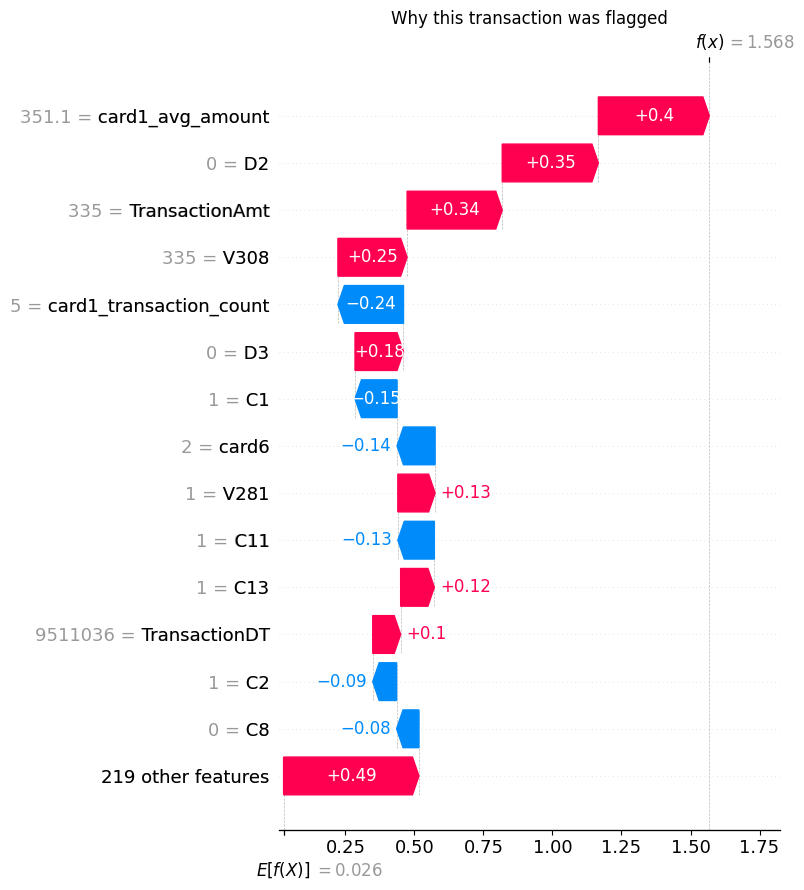

In [21]:
shap.waterfall_plot(
    shap.Explanation(
        values = shap_values[high_risk.index[0]],
        base_values = explainer.expected_value,
        data = X_test.iloc[high_risk.index[0]]
    ),
    max_display=15,
    show = False
)
plt.title('Why this transaction was flagged')
plt.tight_layout()
plt.savefig('../models/shap_waterfall.png', 
            dpi=150, bbox_inches='tight')
plt.show()
